In [9]:
import os
import numpy as np
import laspy
import alphashape
import trimesh
import time
from tqdm import tqdm
import trame

In [3]:
### Exportierte Punktdaten visualisieren

C:\Users\theisen\AppData\Local\anaconda3\Lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (C:\Users\theisen\AppData\Local\anaconda3\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


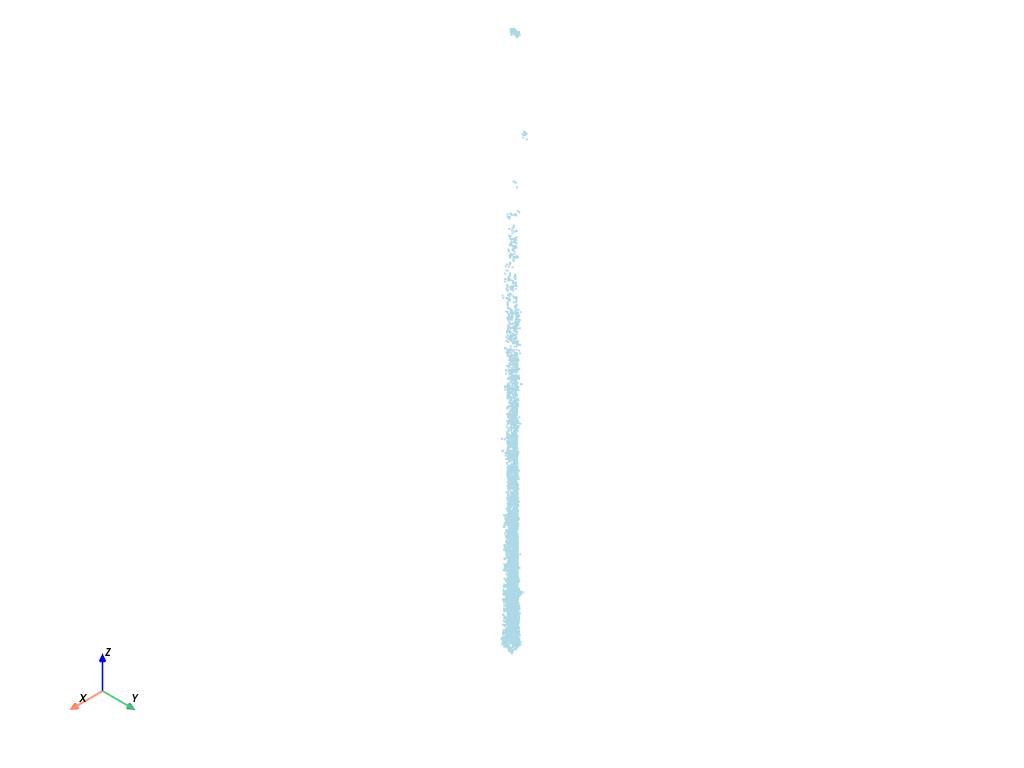

In [11]:
import laspy
import pyvista as pv

# LAS-Datei laden
test_las_wood = r"D:\Marius\R\Wood_middle\Tree_529_stam.las"
las = laspy.read(test_las_wood)

# Punktkoordinaten extrahieren
points = np.vstack((las.x, las.y, las.z)).transpose()

# Pyvista Punktwolke erstellen
cloud = pv.PolyData(points)

# Punktwolke anzeigen
cloud.plot(point_size=2)


In [ ]:
### Hier kann der Alpha-Wert anhand eines Beispieldatensatzes iterativ getestet und festgelegt werden.
# Der Alpah-Wert unterscheidet sich für Äste Stämme und Krone. 
# Er kann in den drei nachfolgenden Codezellen getestet und festgelegt werden.
# Die gewählten Parameter werden für die folgenden Prozesse übernommen.

In [21]:
#testing alpha values
test_las_wood = r"D:\Marius\R\Wood_middle\Tree_529_stam.las"

# LAS-Datei laden
las = laspy.read(test_las_wood)
        
# Zugriff auf die Punktwolke
points = np.vstack((las.x, las.y, las.z)).transpose()

alpha_wood = 4

ashape = alphashape.alphashape(points, alpha_wood)
ashape.show()
    

In [23]:
#testing alpha values
test_las_branch = r"D:\Marius\R\Branch_middle\Tree_529_branch.las"

# LAS-Datei laden
las = laspy.read(test_las_branch)
        
# Zugriff auf die Punktwolke
points = np.vstack((las.x, las.y, las.z)).transpose()

alpha_branch = 6

#for i in alpha:
ashape = alphashape.alphashape(points, alpha_branch)
ashape.show()
    

In [25]:
#testing alpha values
test_las_leaf = r"D:/Marius/R/Leaf_middle/Tree_529_veg_combined.las"

# LAS-Datei laden
las = laspy.read(test_las_leaf)
        
# Zugriff auf die Punktwolke
points = np.vstack((las.x, las.y, las.z)).transpose()

alpha_leaf = 3.5

#for i in alpha:
ashape = alphashape.alphashape(points, alpha_leaf)
ashape.show()
    

In [59]:
# Ausführen um Liste für Zeitmessung zu resetten
times = []

In [61]:
# Working mesh calculation Branch 16.09.24
starttime = time.time()
# Pfade zu den Verzeichnissen
input_folder_branch = r"D:\Marius\R\Branch_middle"
output_folder_branch = r"D:\Marius\R\Branch_middle\OBJ"

# Verzeichnis erstellen
try:
    os.mkdir(output_folder_branch)
    print(f"Verzeichnis '{output_folder_branch}' erfolgreich erstellt.")
except FileExistsError:
    print(f"Das Verzeichnis '{output_folder_branch}' existiert bereits.")

# Liste aller LAS-Dateien im Ordner
segment_files_branch = [f for f in os.listdir(input_folder_branch) if f.endswith('.las')]

# Fortschrittsbalken initialisieren
progress_bar = tqdm(total=len(segment_files_branch), desc='Exporting OBJ files', unit='file')

for file in segment_files_branch:
    try:
        file_path = os.path.join(input_folder_branch, file)
        
        # LAS-Datei laden
        las = laspy.read(file_path)
        
        # Zugriff auf die Punktwolke
        points = np.vstack((las.x, las.y, las.z)).transpose()

        # Überprüfen, ob genügend Punkte vorhanden sind
        if len(points) < 4:  # Weniger als 4 Punkte können kein Volumen bilden
            print(f"Zu wenige Punkte in Datei: {file}")
            continue
        
        # Berechnung des Alpha-Shapes und Dauer des Prozesses
        
        alpha_shape = alphashape.alphashape(points, alpha_branch)

        # Konvertierung des Alpha-Shapes in ein Trimesh-Objekt
        # mesh = trimesh.Trimesh(vertices=alpha_shape.vertices, faces=alpha_shape.faces)
        
        file_name = os.path.splitext(os.path.basename(file))[0]
        output_obj_path = os.path.join(output_folder_branch, f"{file_name}.obj")
        
        # Export in das OBJ-Format
        alpha_shape.export(output_obj_path)

    except Exception as e:
        # Fehlerbehandlung, falls etwas schiefgeht
        print(f"Fehler bei Datei {file}: {e}")
    
    finally:
        # Fortschrittsbalken aktualisieren, auch wenn ein Fehler auftritt
        progress_bar.update(1)

# Fortschrittsbalken abschließen
progress_bar.close()

endtime = time.time()
executiontime = endtime-starttime
times.append(executiontime)
summe_branch=sum(times)/3600
print(f"Der Prozess für Branch dauerte {summe_branch:.2f} Stunden")

Verzeichnis 'D:\Marius\R\Branch_middle\OBJ' erfolgreich erstellt.



Exporting OBJ files:   2%|█▎                                                    | 44/1767 [24:41<16:07:10, 33.68s/file]

Exporting OBJ files:   1%|▌                                                        | 16/1767 [00:27<24:18,  1.20file/s]

Zu wenige Punkte in Datei: Tree_1013_branch.las



Exporting OBJ files:   2%|█▏                                                       | 35/1767 [00:56<59:13,  2.05s/file]

Zu wenige Punkte in Datei: Tree_1036_branch.las


...

Fehler bei Datei Tree_899_branch.las: too many indices for array: array is 1-dimensional, but 2 were indexed



Exporting OBJ files:  98%|███████████████████████████████████████████████████▉ | 1733/1767 [1:02:40<00:22,  1.51file/s]

Fehler bei Datei Tree_965_branch.las: too many indices for array: array is 1-dimensional, but 2 were indexed



Exporting OBJ files: 100%|█████████████████████████████████████████████████████| 1767/1767 [1:04:38<00:00,  2.19s/file]

Der Prozess für Branch dauerte 1.08 Stunden


In [62]:
# Working mesh calculation Wood 16.09.24
starttime_wood = time.time()
# Pfade zu den Verzeichnissen
input_folder_wood = r"D:\Marius\R\Wood_middle"
output_folder_wood = r"D:\Marius\R\Wood_middle\OBJ"

# Verzeichnis erstellen
try:
    os.mkdir(output_folder_wood)
    print(f"Verzeichnis '{output_folder_wood}' erfolgreich erstellt.")
except FileExistsError:
    print(f"Das Verzeichnis '{output_folder_wood}' existiert bereits.")


# Liste aller LAS-Dateien im Ordner
segment_files_wood = [f for f in os.listdir(input_folder_wood) if f.endswith('.las')]

# Fortschrittsbalken initialisieren
progress_bar = tqdm(total=len(segment_files_wood), desc='Exporting OBJ files', unit='file')

for file in segment_files_wood:
    try:
        file_path = os.path.join(input_folder_wood, file)
        
        # LAS-Datei laden
        las = laspy.read(file_path)
        
        # Zugriff auf die Punktwolke
        points = np.vstack((las.x, las.y, las.z)).transpose()

        # Überprüfen, ob genügend Punkte vorhanden sind
        if len(points) < 4:  # Weniger als 4 Punkte können kein Volumen bilden
            print(f"Zu wenige Punkte in Datei: {file}")
            continue
        
        # Berechnung des Alpha-Shapes und Dauer des Prozesses
        alpha_shape = alphashape.alphashape(points, alpha_wood)

        # Konvertierung des Alpha-Shapes in ein Trimesh-Objekt
        # mesh = trimesh.Trimesh(vertices=alpha_shape.vertices, faces=alpha_shape.faces)
        
        file_name = os.path.splitext(os.path.basename(file))[0]
        output_obj_path = os.path.join(output_folder_wood, f"{file_name}.obj")
        
        # Export in das OBJ-Format
        alpha_shape.export(output_obj_path)

    except Exception as e:
        # Fehlerbehandlung, falls etwas schiefgeht
        print(f"Fehler bei Datei {file}: {e}")
    
    finally:
        # Fortschrittsbalken aktualisieren, auch wenn ein Fehler auftritt
        progress_bar.update(1)

# Fortschrittsbalken abschließen
progress_bar.close()
# Dauer berechnen
endtime_wood = time.time()
executiontime_wood = endtime_wood-starttime_wood
times.append(executiontime_wood)
summe_wood=sum(times)/3600
print(f"Der Prozess für Äste und Stämme dauerte {summe_wood:.2f} Stunden")

Verzeichnis 'D:\Marius\R\Wood_middle\OBJ' erfolgreich erstellt.


Exporting OBJ files:   0%|▏                                                       | 5/1886 [00:13<1:14:01,  2.36s/file]

Zu wenige Punkte in Datei: Tree_1005_stam.las


Exporting OBJ files:   4%|██▎                                                      | 75/1886 [01:45<40:16,  1.33s/file]

Zu wenige Punkte in Datei: Tree_106_stam.las


...

Zu wenige Punkte in Datei: Tree_98_stam.las


Exporting OBJ files: 100%|██████████████████████████████████████████████████████▉| 1883/1886 [42:50<00:06,  2.08s/file]

Zu wenige Punkte in Datei: Tree_998_stam.las


Exporting OBJ files: 100%|███████████████████████████████████████████████████████| 1886/1886 [42:52<00:00,  1.36s/file]

Der Prozess für Äste und Stämme dauerte 1.79 Stunden


In [ ]:
# Working mesh calculation Leaf 16.09.24
starttime_leaf = time.time()
# Pfade zu den Verzeichnissen
#input_folder_wood = "F:/ARS/Masterarbeit_Theisen/R/Wood_positive"
input_folder_leaf = r"D:\Marius\R\Leaf_middle"
#output_folder_wood = "F:/ARS/Masterarbeit_Theisen/R/Wood_positive/OBJ"
output_folder_leaf = r"D:\Marius\R\Leaf_middle\OBJ"

# Verzeichnis erstellen
try:
    os.mkdir(output_folder_leaf)
    print(f"Verzeichnis '{output_folder_leaf}' erfolgreich erstellt.")
except FileExistsError:
    print(f"Das Verzeichnis '{output_folder_leaf}' existiert bereits.")

# Liste aller LAS-Dateien im Ordner
#segment_files_wood = [f for f in os.listdir(input_folder_wood) if f.endswith('.las')]
segment_files_leaf = [f for f in os.listdir(input_folder_leaf) if f.endswith('.las')]

# Fortschrittsbalken initialisieren
progress_bar = tqdm(total=len(segment_files_leaf), desc='Exporting OBJ files', unit='file')

for file in segment_files_leaf:
    try:
        file_path = os.path.join(input_folder_leaf, file)
        
        # LAS-Datei laden
        las = laspy.read(file_path)
        
        # Zugriff auf die Punktwolke
        points = np.vstack((las.x, las.y, las.z)).transpose()

        # Überprüfen, ob genügend Punkte vorhanden sind
        if len(points) < 4:  # Weniger als 4 Punkte können kein Volumen bilden
            print(f"Zu wenige Punkte in Datei: {file}")
            continue
        
        # Berechnung des Alpha-Shapes und Dauer des Prozesses
        alpha_shape = alphashape.alphashape(points, alpha_leaf)

        # Konvertierung des Alpha-Shapes in ein Trimesh-Objekt
        # mesh = trimesh.Trimesh(vertices=alpha_shape.vertices, faces=alpha_shape.faces)
        
        file_name = os.path.splitext(os.path.basename(file))[0]
        output_obj_path = os.path.join(output_folder_leaf, f"{file_name}.obj")
        
        # Export in das OBJ-Format
        alpha_shape.export(output_obj_path)

    except Exception as e:
        # Fehlerbehandlung, falls etwas schiefgeht
        print(f"Fehler bei Datei {file}: {e}")
    
    finally:
        # Fortschrittsbalken aktualisieren, auch wenn ein Fehler auftritt
        progress_bar.update(1)

# Fortschrittsbalken abschließen
progress_bar.close()
#Zeitmessung
endtime_leaf = time.time()
executiontime_leaf = endtime_leaf-starttime_leaf
times.append(executiontime_leaf)
summe_leaf=sum(times)/3600
print(f"Der Gesamtprozess dauerte {summe_leaf:.2f} Stunden")

Verzeichnis 'D:\Marius\R\Leaf_middle\OBJ' erfolgreich erstellt.



Exporting OBJ files:  61%|███████████████████████████████▎                   | 488/796 [15:38:48<9:52:31, 115.43s/file]

Exporting OBJ files:   9%|████▊                                              | 183/1962 [2:42:32<34:51:26, 70.54s/file]

In [130]:

"""
def add_material_to_obj(obj_file_path, mtl_file_name, group_name, material_name):
    # OBJ-Datei lesen
    with open(obj_file_path, 'r') as file:
        obj_data = file.readlines()
    
    # Material-Informationen hinzufügen
    obj_data.insert(1, f'mtllib {mtl_file_name}\n')  # Verweis auf die MTL-Datei
    obj_data.insert(2, f'g {group_name}\n')
    obj_data.insert(3, f'usemtl {material_name}\n')  # Material für das Mesh verwenden
    
    # Neue OBJ-Datei mit Material schreiben
    new_obj_file_path = obj_file_path.replace('.obj', '_mit_material.obj')
    with open(new_obj_file_path, 'w') as file:
        file.writelines(obj_data)
    
    print(f"Neue OBJ-Datei mit Material erstellt: {new_obj_file_path}")
"""



In [132]:
"""
# Add Material Information

add_material_to_obj(mesh_path, 'Ettenheim.mtl', 'leaf', 'leaf')
"""

Neue OBJ-Datei mit Material erstellt: F:/ARS/Masterarbeit_Theisen/R/Leaf/OBJ/Tree_100_veg_combined_mit_material.obj


In [8]:
def add_material_to_obj(mesh_path, mtl_filename, mtl_name, group_name, output_path):
    """
    Fügt Materialinformationen zu einer OBJ-Datei hinzu und speichert sie im Ausgabeverzeichnis.
    
    :param mesh_path: Pfad zur Eingabe-OBJ-Datei
    :param mtl_filename: Name der MTL-Datei
    :param mtl_name: Name des Materials in der MTL-Datei
    :param group_name: Name der Gruppe in der OBJ-Datei
    :param output_path: Pfad zum Ausgabeverzeichnis
    """
    with open(mesh_path, 'r') as file:
        obj_data = file.readlines()

    # Materialzuweisungen in die OBJ-Datei einfügen
    obj_data.insert(1, f'mtllib {mtl_filename}\n')  # Verweis auf die MTL-Datei
    obj_data.insert(2, f'usemtl {material_name}\n')      # Material für das Mesh verwenden
    obj_data.insert(3, f'g {group_name}\n')         # Gruppe für das Mesh setzen

    # Vollständiger Pfad zur Ausgabedatei erstellen
    base_name = os.path.basename(mesh_path)
    output_file_path = os.path.join(output_path, base_name)

    # Die aktualisierte OBJ-Datei im Ausgabeverzeichnis speichern
    with open(output_file_path, 'w') as file:
        file.writelines(obj_data)

def process_all_objs_in_folder(input_folder_path, output_folder_path, mtl_filename, mtl_name, group_name):
    """
    Verarbeitet alle OBJ-Dateien in einem Eingabeverzeichnis und speichert die bearbeiteten Dateien in einem Ausgabeverzeichnis.
    
    :param input_folder_path: Pfad zum Eingabeverzeichnis
    :param output_folder_path: Pfad zum Ausgabeverzeichnis
    :param mtl_filename: Name der MTL-Datei
    :param mtl_name: Name des Materials in der MTL-Datei
    :param group_name: Name der Gruppe in der OBJ-Datei
    """
    # Erstelle das Ausgabeverzeichnis, falls es nicht existiert
    if not os.path.exists(output_folder_path):
        os.makedirs(output_folder_path)
    
    # Durchlaufe alle Dateien im Eingabeverzeichnis
    for filename in os.listdir(input_folder_path):
        # Überprüfe, ob es sich um eine .obj-Datei handelt
        if filename.endswith('.obj'):
            # Vollständiger Pfad zur Eingabe-OBJ-Datei
            obj_path = os.path.join(input_folder_path, filename)
            # Wende die Funktion auf die aktuelle OBJ-Datei an
            add_material_to_obj(obj_path, mtl_filename, material_name, group_name, output_folder_path)
            print(f"Material hinzugefügt zu {filename}, gespeichert in {output_folder_path}")



In [10]:

# Add Mtl-Information for leaf objs

input_folder_path = 'F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ'   # Ordner, der die .obj-Dateien enthält
output_folder_path = 'F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl' # Ordner, in dem die bearbeiteten .obj-Dateien gespeichert werden
mtl_filename = 'Ettenheim.mtl'                      # Name der MTL-Datei
material_name = 'leaf'                                 # Materialname in der MTL-Datei
group_name = 'leaf'                               # Name der Gruppe in der OBJ-Datei

# Alle OBJ-Dateien im Eingabeverzeichnis verarbeiten und im Ausgabeverzeichnis speichern
process_all_objs_in_folder(input_folder_path, output_folder_path, mtl_filename, material_name, group_name)

Material hinzugefügt zu Tree_100_veg_combined.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_101_veg_combined.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_102_veg_combined.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_103_veg_combined.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_104_veg_combined.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_105_veg_combined.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_106_veg_combined.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_107_veg_combined.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_108_veg_com

In [12]:

# Add Mtl-Information for bark objs

input_folder_path = 'F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ'   # Ordner, der die .obj-Dateien enthält
output_folder_path = 'F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl' # Ordner, in dem die bearbeiteten .obj-Dateien gespeichert werden
mtl_filename = 'Ettenheim.mtl'                      # Name der MTL-Datei
material_name = 'bark'                                 # Materialname in der MTL-Datei
group_name = 'bark'                               # Name der Gruppe in der OBJ-Datei

# Alle OBJ-Dateien im Eingabeverzeichnis verarbeiten und im Ausgabeverzeichnis speichern
process_all_objs_in_folder(input_folder_path, output_folder_path, mtl_filename, material_name, group_name)

Material hinzugefügt zu Tree_0_stam_branch.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_100_stam_branch.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_101_stam_branch.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_102_stam_branch.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_103_stam_branch.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_104_stam_branch.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_105_stam_branch.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_107_stam_branch.obj, gespeichert in F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl
Material hinzugefügt zu Tree_109_stam_branch.obj, 

In [14]:
def write_mtl(file_path):
    # Inhalt der MTL-Datei definieren
    mtl_content = """newmtl leaf
Kd 0.216602185664037 0.264186213266441 0.235329808918338
d 0.919144359320093
illum 7
Ns 215

newmtl bark
Kd 0.373477701238402 0.355248963063045 0.328943605236245
d 1
illum 7
Ns 215
"""
    # Datei schreiben
    with open(file_path, 'w') as mtl_file:
        mtl_file.write(mtl_content)


In [16]:
# write mtl file leaf
write_mtl('F:/ARS/Masterarbeit_Theisen/R/Leaf_middle/OBJ/OBJ_Mtl/Ettenheim.mtl')

In [18]:
# write mtl file Wood
write_mtl('F:/ARS/Masterarbeit_Theisen/R/Wood_middle/OBJ/OBJ_Mtl/Ettenheim.mtl')

In [1]:
# Tiff des DGM's aus R in Ply-File für Blender konvertieren
import sys
import numpy as np
from osgeo import gdal

def write_ply(filename, coordinates, triangles, binary=True):
    template = "ply\n"
    if binary:
        template += "format binary_" + sys.byteorder + "_endian 1.0\n"
    else:
        template += "format ascii 1.0\n"
    template += """element vertex {nvertices:n}
property float x
property float y
property float z
element face {nfaces:n}
property list int int vertex_index
end_header
"""

    context = {
     "nvertices": len(coordinates),
     "nfaces": len(triangles)
    }

    if binary:
        with open(filename, 'wb') as outfile:
            outfile.write(template.format(**context).encode('utf-8'))
            coordinates = np.array(coordinates, dtype="float32")
            coordinates.tofile(outfile)

            triangles = np.hstack((np.ones([len(triangles), 1], dtype="int") * 3,
                                   triangles))
            triangles = np.array(triangles, dtype="int32")
            triangles.tofile(outfile)
    else:
        with open(filename, 'w') as outfile:
            outfile.write(template.format(**context))
            np.savetxt(outfile, coordinates, fmt="%.3f")
            np.savetxt(outfile, triangles, fmt="3 %i %i %i")

def readraster(filename):
    raster = gdal.Open(filename)
    return raster

def createvertexarray(raster):
    transform = raster.GetGeoTransform()
    width = raster.RasterXSize
    height = raster.RasterYSize
    x = np.arange(0, width) * transform[1] + transform[0]
    y = np.arange(0, height) * transform[5] + transform[3]
    xx, yy = np.meshgrid(x, y)
    zz = raster.ReadAsArray()
    vertices = np.vstack((xx, yy, zz)).reshape([3, -1]).transpose()
    return vertices

def createindexarray(raster):
    width = raster.RasterXSize
    height = raster.RasterYSize

    ai = np.arange(0, width - 1)
    aj = np.arange(0, height - 1)
    aii, ajj = np.meshgrid(ai, aj)
    a = aii + ajj * width
    a = a.flatten()

    tria = np.vstack((a, a + width, a + width + 1, a, a + width + 1, a + 1))
    tria = np.transpose(tria).reshape([-1, 3])
    return tria

# Hauptteil der Funktion - Eingabewerte direkt setzen
def main():
    # Gebe den Input- und Output-Dateipfad hier direkt an
    inputfile = r"D:\Marius\R\output\lidr_ground_963.tif"  # Dein Raster-Dateipfad
    outputfile = r"D:\Marius\R\output\lidr_ground_963.ply"  # Dein Ausgabepfad

    # Raster lesen und Umwandlung in PLY
    raster = readraster(inputfile)
    vertices = createvertexarray(raster)
    triangles = createindexarray(raster)

    # PLY-Datei schreiben
    write_ply(outputfile, vertices, triangles, binary=True)

# Funktion direkt ausführen
if __name__ == "__main__":
    main()